# 8. Redes Neuronales con TensorFlow

**Punto de partida:** los artefactos guardados en `../models/` — `data.pkl` y `metrics.pkl` de `4_Modeling.ipynb` (misma partición train/test y mismo escalamiento), y `modelos_optimizados.pkl` de `5_ModelOptimization.ipynb` (los tres modelos clásicos ya afinados con `GridSearchCV`). Comparar la red contra los modelos **optimizados**, y no contra sus versiones por defecto, es una comparación más justa.

**Objetivo del notebook:** construir un **Perceptrón Multicapa (MLP)** con `TensorFlow`/`Keras` para predecir `churn`, cerrando el arco de clasificación del curso (`4_Modeling.ipynb` → `5_ModelOptimization.ipynb` → este notebook) con una familia de modelos completamente distinta: redes neuronales en lugar de los algoritmos clásicos de `scikit-learn`.

### ¿Qué es una red neuronal?
Una red neuronal es una función compuesta por capas de **neuronas artificiales**. Cada neurona calcula una suma ponderada de sus entradas, le suma un sesgo (*bias*) y aplica una **función de activación** no lineal (por ejemplo `ReLU`). Apilar varias de estas capas permite que la red aprenda relaciones complejas y no lineales entre las variables — algo que la Regresión Logística, al ser un modelo lineal, no puede capturar por sí sola.

Conceptos clave que aparecen a lo largo del notebook:

- **Capa de entrada**: recibe las variables predictoras (una neurona por variable).
- **Capas ocultas**: transforman la información en representaciones intermedias.
- **Capa de salida**: en este caso, una sola neurona con activación `sigmoid` que produce una   probabilidad entre 0 y 1 — la misma idea que la salida de una Regresión Logística.
- **Función de pérdida** (`loss`): mide qué tan lejos están las predicciones de los valores reales; la   red ajusta sus pesos para minimizarla.
- **Optimizador**: el algoritmo que ajusta los pesos en cada paso, usando el gradiente de la función de   pérdida (*descenso de gradiente* y sus variantes).
- **Época (epoch)**: una pasada completa por todos los datos de entrenamiento. **Batch**: un subconjunto   de datos usado para calcular un paso de actualización de pesos (en vez de usar todo el dataset de una   sola vez).

Se reutilizan `pandas`, `numpy`, `matplotlib`, `seaborn` y `joblib`. Lo nuevo frente a los módulos anteriores es `tensorflow` (con su API de alto nivel `keras`), y de `scikit-learn` solo se importan funciones de métricas — no algoritmos — ya que el modelo en sí se construye con `Keras`.

In [1]:
# Plomería del entorno (no es parte del análisis): se fija la versión de
# scikit-learn. Los modelos serializados en ../models/*.pkl se guardaron con la
# 1.9.0, y joblib.load() advierte o falla al abrirlos con una versión distinta.
# %pip install -q scikit-learn==1.9.0

# import sklearn
# print("scikit-learn:", sklearn.__version__)
# if sklearn.__version__ != "1.9.0":
#     print("Versión distinta a la esperada (1.9.0).")
#     print("En Colab: menú Entorno de ejecución > Reiniciar sesión, y ejecuta de nuevo esta celda.")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.15.1


## Parámetros del experimento

- **`target`**: `"churn"`, igual que en `4_Modeling.ipynb`.
- **`metric`**: `"roc_auc"`, para comparar en el mismo criterio usado como referencia principal en   `4_Modeling.ipynb`.
- **`RANDOM_STATE`**: se fija tanto para `numpy` como para `tensorflow`. A diferencia de   `scikit-learn` (donde `random_state` alcanza para reproducibilidad), `TensorFlow` tiene su propia   fuente de aleatoriedad (inicialización de pesos, orden de los batches) y requiere fijar su propia   semilla por separado.

In [3]:
target = "churn"
metric = "roc_auc"
RANDOM_STATE = 123

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## Cargar datos y modelos clásicos

Se reutiliza `data.pkl` de `4_Modeling.ipynb`: la misma partición `train`/`test`, y `X_train_scaled` / `X_test_scaled` (donde `tenure` y `MonthlyCharges` ya están estandarizados y las variables binarias quedan en su rango original [0,1]). Las redes neuronales, igual que la Regresión Logística, entrenan más rápido y de forma más estable cuando las variables de entrada están en escalas comparables — por eso se usa la versión escalada, no `X_train` original.

También se cargan `modelos_optimizados.pkl` (los tres modelos clásicos ya afinados en `5_ModelOptimization.ipynb` — no los de `4_Modeling.ipynb` sin optimizar) y `metrics.pkl`, para comparar la red neuronal contra ellos al final del notebook. `modelos_optimizados.pkl` guarda directamente cada estimador ya entrenado (`grid_search[name].best_estimator_`), por eso el loop más adelante puede llamar `model.predict_proba(...)` sin pasar por una llave `["model"]` intermedia, a diferencia de cómo se accedía a `modelos_entrenados.pkl` en notebooks anteriores.

In [4]:
data_dict = joblib.load("../models/data.pkl")
X_train, y_train = data_dict["X_train"], data_dict["y_train"]
X_test, y_test = data_dict["X_test"], data_dict["y_test"]
X_train_scaled, X_test_scaled = data_dict["X_train_scaled"], data_dict["X_test_scaled"]

modelos_clasicos = joblib.load("../models/modelos_optimizados.pkl")
metrics_dict = joblib.load("../models/metrics.pkl")
test_metrics_clasicos = metrics_dict["test_metrics"]

print(f"{X_train_scaled.shape=}, {X_test_scaled.shape=}")
test_metrics_clasicos

X_train_scaled.shape=(5634, 24), X_test_scaled.shape=(1409, 24)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.800568,0.653465,0.529412,0.584934,0.843452
DecisionTree,0.728176,0.488127,0.494652,0.491368,0.656741
RandomForest,0.787793,0.624585,0.502674,0.557037,0.813078


## Arquitectura de la red

Se construye un MLP simple con `keras.Sequential` (una pila de capas, cada una recibe la salida de la anterior):

- **Capa de entrada**: tantas neuronas como columnas tenga `X_train_scaled`.
- **Dos capas ocultas** (`Dense`) con activación `ReLU` (32 y 16 neuronas respectivamente) — el número   de neuronas y de capas es un hiperparámetro más; esta es una arquitectura de partida razonable para   un dataset tabular de este tamaño, no una regla fija.
- **Capa de salida**: 1 neurona con activación `sigmoid`, que produce la probabilidad de `churn`.

In [5]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

### Compilar el modelo

- **`loss="binary_crossentropy"`**: la función de pérdida estándar para clasificación binaria,   equivalente conceptual a la función que optimiza la Regresión Logística internamente.
- **`optimizer="adam"`**: una variante de descenso de gradiente que adapta la tasa de aprendizaje   automáticamente durante el entrenamiento; es la opción por defecto más usada en la práctica.
- **`metrics`**: además de `accuracy`, se hace seguimiento de `AUC`, `Precision` y `Recall` durante el   entrenamiento — las mismas métricas ya familiares de `4_Modeling.ipynb`.

In [6]:
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ]
)

## Entrenamiento

A diferencia de los modelos de `scikit-learn` (que se ajustan con una sola llamada a `.fit()`), una red neuronal se entrena de forma **iterativa** a lo largo de varias épocas, y es fácil que termine sobreajustada si se entrena por demasiadas. Dos mecanismos ayudan a controlar esto:

- **`validation_split=0.2`**: reserva el 20% de `X_train_scaled` (no toca `X_test_scaled` en ningún   momento) para monitorear el desempeño en datos no vistos *durante* el entrenamiento, época a época.
- **`EarlyStopping`**: detiene el entrenamiento automáticamente si la pérdida de validación (`val_loss`)   deja de mejorar durante `patience` épocas seguidas, y restaura los pesos de la mejor época   (`restore_best_weights=True`) — evita tener que adivinar de antemano el número exacto de épocas.

In [7]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

print(f"Entrenamiento detenido en la época {len(history.history['loss'])} (de un máximo de 100)")

Entrenamiento detenido en la época 19 (de un máximo de 100)


### Curvas de entrenamiento

Se grafican la pérdida y el AUC para `train` y para el conjunto de validación, época a época. Es el diagnóstico de sobreajuste específico de redes neuronales — el equivalente visual a comparar `train` vs. `test` en las tablas de métricas de los módulos anteriores, pero mostrando *cómo evoluciona* esa brecha en vez de un solo número final.

**Qué buscar:** si la curva de `train` sigue mejorando mientras la de validación se estanca o empeora, es señal de sobreajuste — justo lo que `EarlyStopping` busca evitar deteniendo el entrenamiento a tiempo.

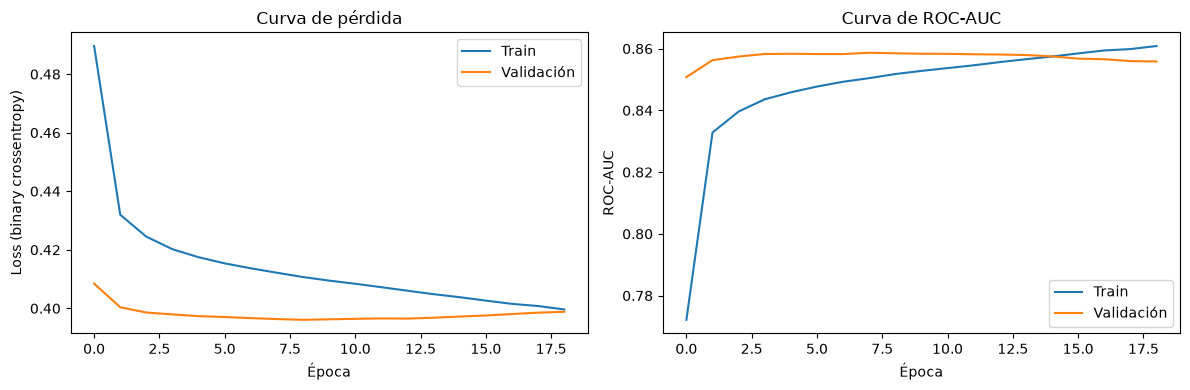

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss (binary crossentropy)")
axes[0].set_title("Curva de pérdida")
axes[0].legend()

axes[1].plot(history.history["auc"], label="Train")
axes[1].plot(history.history["val_auc"], label="Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Curva de ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluar desempeño en test

El modelo produce probabilidades (salida de la capa `sigmoid`); se convierten a clase con un umbral de `0.5`, el mismo criterio implícito que usa `scikit-learn` en `.predict()` para clasificación binaria.

In [9]:
y_proba_test = nn_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_test = (y_proba_test >= 0.5).astype(int)

nn_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred_test),
    "precision": precision_score(y_test, y_pred_test),
    "recall": recall_score(y_test, y_pred_test),
    "f1": f1_score(y_test, y_pred_test),
    "roc_auc": roc_auc_score(y_test, y_proba_test),
}, name="NeuralNetwork")

nn_metrics.to_frame().T

,accuracy,precision,recall,f1,roc_auc
NeuralNetwork,0.79489,0.644068,0.508021,0.568012,0.840846


### Matriz de confusión

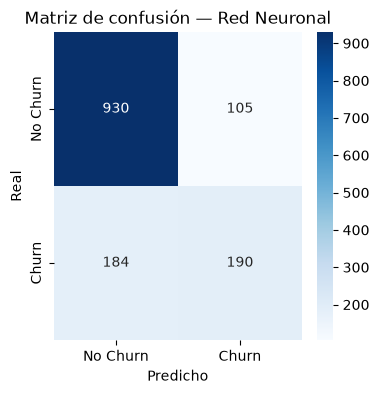

In [10]:
c_matrix_nn = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(4, 4))
sns.heatmap(c_matrix_nn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — Red Neuronal")
plt.show()

## Comparación contra los modelos clásicos optimizados

Se grafican, en un solo plano, las curvas ROC de los tres modelos **ya optimizados** en `5_ModelOptimization.ipynb` (Regresión Logística, Decision Tree, Random Forest) junto con la de la red neuronal — reutilizando `modelos_clasicos` cargado al inicio del notebook, sin necesidad de reentrenar nada.

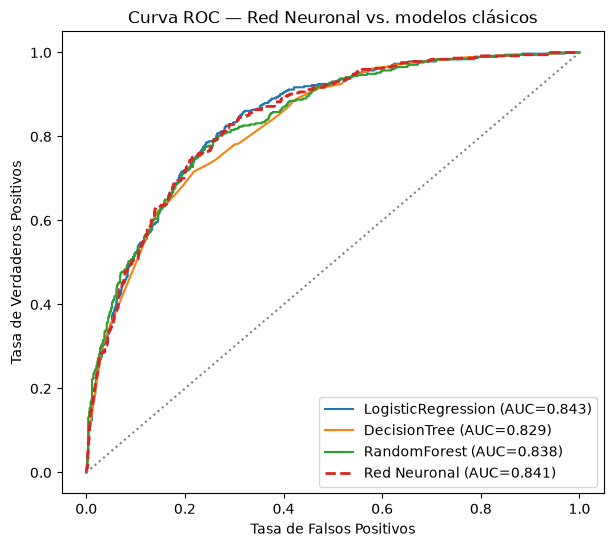

In [11]:
plt.figure(figsize=(7, 6))

for name, model in modelos_clasicos.items():
    X_ = X_test_scaled if name == "LogisticRegression" else X_test
    y_proba = model.predict_proba(X_)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_test)
auc_nn = roc_auc_score(y_test, y_proba_test)
plt.plot(fpr_nn, tpr_nn, label=f"Red Neuronal (AUC={auc_nn:.3f})", linewidth=2, linestyle="--")

plt.plot([0, 1], [0, 1], linestyle=":", color="gray")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC — Red Neuronal vs. modelos clásicos")
plt.legend()
plt.show()

### Tabla comparativa final

In [12]:
comparacion_final = pd.concat([test_metrics_clasicos, nn_metrics.to_frame().T])
comparacion_final.sort_values(metric, ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.800568,0.653465,0.529412,0.584934,0.843452
NeuralNetwork,0.794890,0.644068,0.508021,0.568012,0.840846
RandomForest,0.787793,0.624585,0.502674,0.557037,0.813078
DecisionTree,0.728176,0.488127,0.494652,0.491368,0.656741


**Interpretación:** en datasets tabulares de tamaño moderado como este (~7 mil registros, ~24 variables), es común que las redes neuronales *no* superen claramente a Random Forest — las redes suelen aportar mayor ventaja relativa con muchos más datos, o con estructuras espaciales/secuenciales (imágenes, texto, series de tiempo) donde los modelos clásicos no tienen forma natural de representar la información. Compara el `roc_auc` de la tabla anterior con el resultado obtenido en tu ejecución: si la red neuronal no gana, no es un error — es una observación empírica legítima y común en este tipo de problema.

## Regularización con Dropout (técnica adicional)

Una técnica común para reducir sobreajuste en redes neuronales es **Dropout**: durante el entrenamiento, apaga aleatoriamente un porcentaje de neuronas en cada paso, forzando a la red a no depender demasiado de neuronas individuales — un efecto similar en espíritu a lo que un ensamble como Random Forest logra promediando muchos árboles distintos. Se entrena una segunda arquitectura, idéntica a la anterior salvo por las capas `Dropout`, para comparar si mejora la generalización.

In [13]:
model_dropout = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history_dropout = model_dropout.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0,
)

y_proba_dropout = model_dropout.predict(X_test_scaled, verbose=0).ravel()

print(f"ROC-AUC sin Dropout: {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"ROC-AUC con Dropout: {roc_auc_score(y_test, y_proba_dropout):.4f}")

ROC-AUC sin Dropout: 0.8408
ROC-AUC con Dropout: 0.8427


## Prueba con un cliente nuevo

Como en los módulos anteriores, se simula el uso del modelo con un registro real del conjunto de `test` (`X_test_scaled`, consistente con cómo se entrenó la red), buscado directamente por su `customerID`.

In [14]:
id_busq = "3158-MOERK"
print(f"{id_busq=}")
new_customer = X_test_scaled.loc[[id_busq]]
new_customer.T

id_busq='3158-MOERK'


customerID,3158-MOERK
gender,1.000000
seniorcitizen,0.000000
partner,0.000000
dependents,0.000000
tenure,-1.231536
phoneservice,1.000000
multiplelines,1.000000
onlinesecurity,0.000000
onlinebackup,0.000000
deviceprotection,0.000000


In [15]:
prob_churn = nn_model.predict(new_customer, verbose=0)[0][0]

print(f"Probabilidad de churn estimada para '{id_busq}': {prob_churn:.1%}")
print(f"Clase predicha: {'Churn' if prob_churn >= 0.5 else 'No Churn'}")
print(f"Valor real registrado: {'Churn' if y_test.loc[id_busq] == 1 else 'No Churn'}")

Probabilidad de churn estimada para '3158-MOERK': 77.7%
Clase predicha: Churn
Valor real registrado: Churn


## Guardar el modelo

A diferencia de los modelos de `scikit-learn` (guardados con `joblib` en los módulos anteriores), los modelos de `Keras`/`TensorFlow` se guardan con su propio método `.save()`, en el formato nativo `.keras` — que conserva la arquitectura, los pesos entrenados y la configuración del optimizador en un solo archivo. Las métricas sí se guardan con `joblib`, igual que en el resto del proyecto, para poder reutilizarlas o compararlas más adelante sin tener que reentrenar.

In [16]:
nn_model.save("../models/nn_churn.keras")
joblib.dump(nn_metrics, "../models/nn_metrics.pkl")

print("Modelo de red neuronal guardado en ../models/nn_churn.keras")

Modelo de red neuronal guardado en ../models/nn_churn.keras


## Conclusiones y siguientes pasos

Este notebook cierra el arco de clasificación del curso (`4_Modeling.ipynb` → `5_ModelOptimization.ipynb` → `8_NN.ipynb`) con una familia de modelos distinta a los algoritmos clásicos de `scikit-learn`, reutilizando en todo momento la misma partición de datos para que las comparaciones fueran justas. Próximos pasos posibles:

1. **Búsqueda de hiperparámetros de la red** (número de capas, neuronas por capa, tasa de    aprendizaje, tamaño de batch) con herramientas como `Keras Tuner`, en el mismo espíritu que    `GridSearchCV`/`RandomizedSearchCV` en `5_ModelOptimization.ipynb` — pero adaptado al costo    computacional propio de entrenar redes neuronales.
2. **Variables categóricas como *embeddings*** en lugar de One-Hot Encoding: una representación    aprendida por la propia red, más eficiente que columnas dummy cuando hay muchas categorías.
3. **Interpretabilidad**: técnicas como `SHAP` también aplican a redes neuronales (no solo a modelos    de árboles), para entender qué variables más influyen en cada predicción individual.
4. **Despliegue**: `TensorFlow Serving` o la conversión a `TensorFlow Lite` (`.tflite`) son los caminos    típicos para llevar un modelo de `Keras` a producción, análogos en propósito a cargar un `.pkl` con    `joblib` en los módulos anteriores, pero pensados para escenarios de mayor volumen o dispositivos    con recursos limitados.